In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os

os.chdir(r'C:\Users\Kajal\ML_Projects\Project9_smart-city-traffic-patterns\Project9_smart-city-traffic-patterns\Project9_smart-city-traffic-patterns\smart-city-traffic-patterns')

df2 = pd.read_csv('train_aWnotuB.csv')
df2['DateTime'] = pd.to_datetime(df2['DateTime'])

print("Shape:", df2.shape)
df2.head()

Shape: (48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [5]:
print(df2.info())
print("\nMissing values:\n", df2.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB
None

Missing values:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


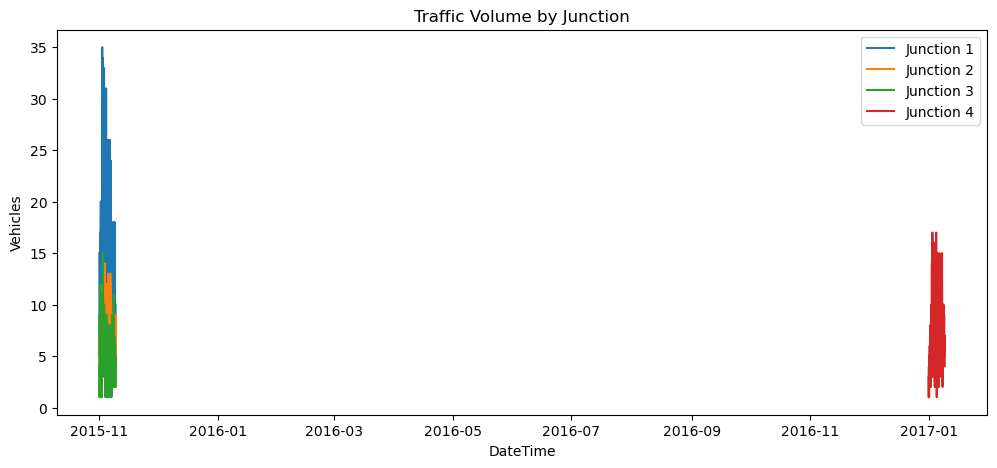

In [6]:
plt.figure(figsize=(12,5))
for junction in df2['Junction'].unique():
    subset = df2[df2['Junction'] == junction]
    plt.plot(subset['DateTime'][:200],
             subset['Vehicles'][:200],
             label=f'Junction {junction}')
plt.title('Traffic Volume by Junction')
plt.xlabel('DateTime')
plt.ylabel('Vehicles')
plt.legend()
plt.show()

In [7]:
df2['hour'] = df2['DateTime'].dt.hour
df2['day_of_week'] = df2['DateTime'].dt.dayofweek
df2['month'] = df2['DateTime'].dt.month
df2['is_weekend'] = df2['day_of_week'].isin([5,6]).astype(int)

print("New features added!")
df2.head()

New features added!


,DateTime,Junction,Vehicles,ID,hour,day_of_week,month,is_weekend
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,1
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,1
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,1
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,1
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,1


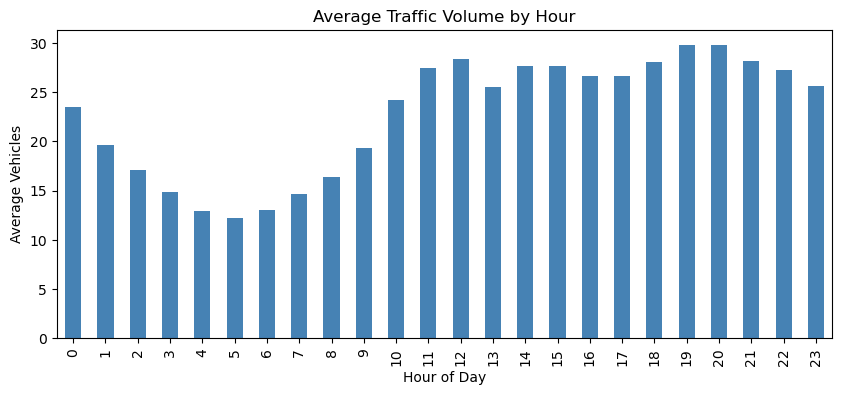

In [8]:
hourly = df2.groupby('hour')['Vehicles'].mean()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar', color='steelblue')
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Vehicles')
plt.show()

Traffic RMSE: 11.08
Traffic MAE: 7.57


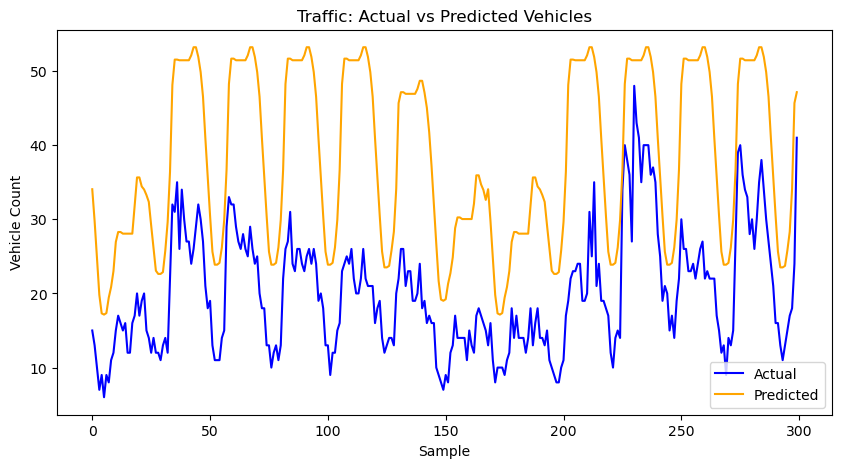

In [9]:
features2 = ['hour','day_of_week','month','is_weekend','Junction']
X2 = df2[features2]
y2 = df2['Vehicles']

model2 = GradientBoostingRegressor(n_estimators=100, random_state=42)
model2.fit(X2, y2)

preds2 = model2.predict(X2)
rmse2 = np.sqrt(mean_squared_error(y2, preds2))
mae2 = mean_absolute_error(y2, preds2)
print(f"Traffic RMSE: {rmse2:.2f}")
print(f"Traffic MAE: {mae2:.2f}")

plt.figure(figsize=(10,5))
plt.plot(y2.values[:300], label='Actual', color='blue')
plt.plot(preds2[:300], label='Predicted', color='orange')
plt.title('Traffic: Actual vs Predicted Vehicles')
plt.xlabel('Sample')
plt.ylabel('Vehicle Count')
plt.legend()
plt.show()